# Tutorial: Online Conformal Prediction with `online-cp`

This tutorial teaches conformal prediction through the lens of **questions you'd naturally ask** when building a prediction system:

1. [How uncertain should I be?](#1.-How-uncertain-should-I-be?) — Regression with Ridge, Kernel Ridge, and Lasso
2. [What about classification?](#2.-What-about-classification?) — Prediction sets with KNN and SVM, plus calibrated probabilities with Venn-Abers
3. [Is it fair to everyone?](#3.-Is-it-fair-to-everyone?) — Mondrian CP for group-conditional coverage
4. [What's the full picture?](#4.-What's-the-full-picture?) — Conformal Predictive Systems
5. [Can I trust my data?](#5.-Can-I-trust-my-data?) — Martingales for detecting distribution shift
6. [What should I do?](#6.-What-should-I-do?) — Decision-making with utility functions and `ConformalPredictiveDecisionMaker`
7. [Putting it into production](#7.-Putting-it-into-production) — Streaming evaluation and plotting utilities

**Prerequisites**: Basic familiarity with supervised learning. No conformal prediction background needed.

**Core guarantee**: Given exchangeable data and significance level $\varepsilon$, a conformal predictor produces sets $\Gamma^\varepsilon$ satisfying $\mathbb{P}(y_{\text{new}} \in \Gamma^\varepsilon) \geq 1 - \varepsilon$ — with no distributional assumptions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_wine, load_breast_cancer

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(42)

---
## 1. How uncertain should I be?

You have a regression model. For each prediction, you want an interval $[l, u]$ that **provably** contains the true value at least $1 - \varepsilon$ of the time — regardless of the data distribution.

### 1.1 Ridge regression on real data

We'll use the California Housing dataset. The data must be **randomly permuted** to satisfy the exchangeability assumption (the raw data is geographically ordered).

In [2]:
from online_cp import ConformalRidgeRegressor, ErrorRate, IntervalWidth, WinklerScore
from online_cp.evaluate import progressive_val
from online_cp.plotting import plot_coverage, plot_intervals

# Load and randomly permute for exchangeability
housing = fetch_california_housing()
perm = rng.permutation(len(housing.target))
X_h, y_h = housing.data[perm[:600]], housing.target[perm[:600]]

# Create model, seed with 50 initial examples
model = ConformalRidgeRegressor(a=1.0)
model.learn_initial_training_set(X_h[:50], y_h[:50])

# Test-then-train on the remaining 550 points
metric = ErrorRate() + IntervalWidth() + WinklerScore()
progressive_val(model, X_h[50:], y_h[50:], epsilon=0.1, metric=metric)

print(metric)

ErrorRate: 0.1218
IntervalWidth: 2.2805
WinklerScore: 3.1423


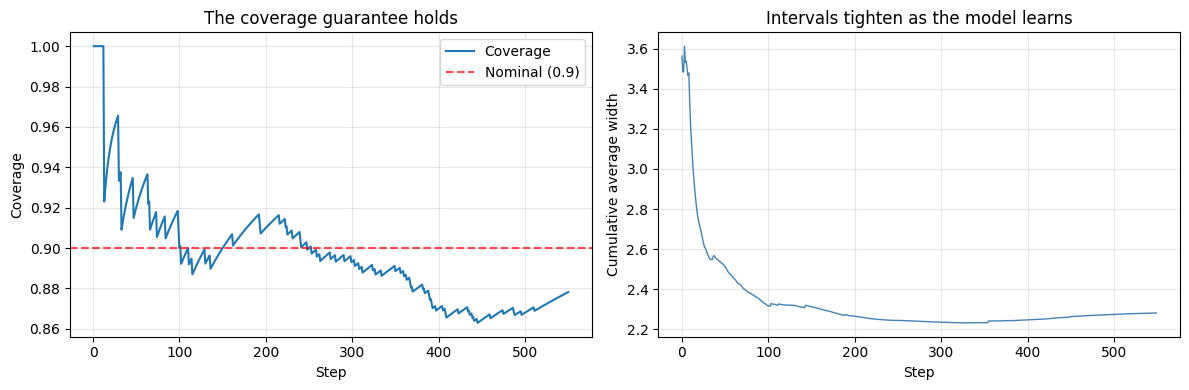

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# The guarantee in action: coverage converges to 1 - ε
plot_coverage(metric["ErrorRate"], nominal=0.9, ax=axes[0])
axes[0].set_title("The coverage guarantee holds")

# Intervals tighten as the model learns more
widths = metric["IntervalWidth"].cumulative_mean()
axes[1].plot(widths, color="steelblue", linewidth=1)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Cumulative average width")
axes[1].set_title("Intervals tighten as the model learns")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

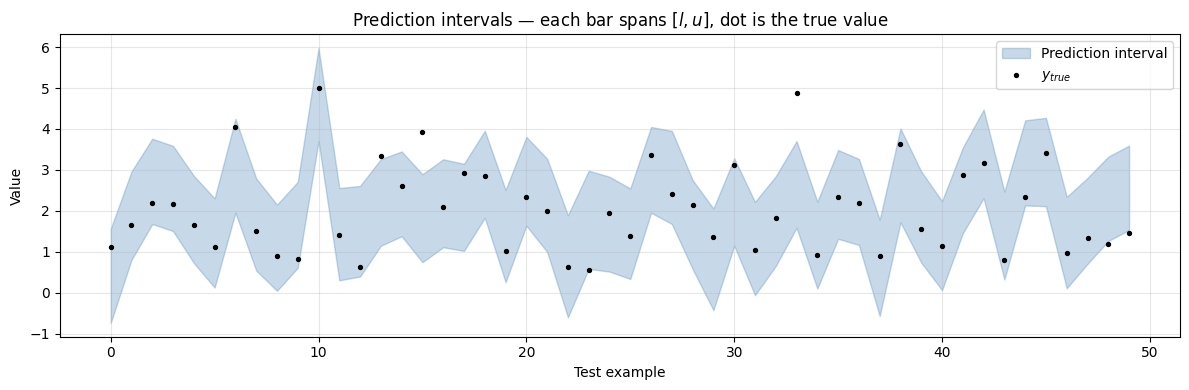

In [4]:
# Visualise individual intervals: does the true value fall inside?
# Collect 40 intervals from a fresh model (so predictions are genuine test-time)
model_iv = ConformalRidgeRegressor(a=1.0)
model_iv.learn_initial_training_set(X_h[:100], y_h[:100])
intervals_iv = [model_iv.predict(X_h[100 + j], epsilon=0.1) for j in range(50)]

fig, ax = plt.subplots(figsize=(12, 4))
plot_intervals(y_h[100:150], intervals_iv, ax=ax)
ax.set_title("Prediction intervals — each bar spans $[l, u]$, dot is the true value")
ax.set_xlabel("Test example")
plt.tight_layout()
plt.show()


The left plot shows the key result: the empirical coverage converges to (at least) the guaranteed $1 - \varepsilon = 0.9$ level. The right plot shows that intervals become tighter over time as the model has more data to calibrate against.

### 1.2 Kernel Ridge — nonlinear data

When the relationship between features and response is nonlinear, a linear model produces unnecessarily wide intervals. `KernelConformalRidgeRegressor` uses kernel methods to capture nonlinear structure:

In [5]:
from online_cp import KernelConformalRidgeRegressor, GaussianKernel

# Synthetic nonlinear data
N_nl = 500
X_nl = rng.uniform(-3, 3, (N_nl, 2))
y_nl = np.sin(X_nl[:, 0]) + 0.5 * X_nl[:, 1]**2 + rng.normal(0, 0.3, N_nl)

# Compare linear vs kernel
linear = ConformalRidgeRegressor(a=1.0)
linear.learn_initial_training_set(X_nl[:50], y_nl[:50])
m_linear = ErrorRate() + IntervalWidth()
progressive_val(linear, X_nl[50:], y_nl[50:], epsilon=0.1, metric=m_linear)

kernel_model = KernelConformalRidgeRegressor(kernel=GaussianKernel(sigma=1.5), a=0.5)
kernel_model.learn_initial_training_set(X_nl[:50], y_nl[:50])
m_kernel = ErrorRate() + IntervalWidth()
progressive_val(kernel_model, X_nl[50:], y_nl[50:], epsilon=0.1, metric=m_kernel)

print(f"Linear ridge:  {m_linear}")
print(f"Kernel ridge:  {m_kernel}")
print(f"\n→ Both satisfy the coverage guarantee, but the kernel model is more efficient.")

Linear ridge:  ErrorRate: 0.1044
IntervalWidth: 4.6912
Kernel ridge:  ErrorRate: 0.1156
IntervalWidth: 1.3424

→ Both satisfy the coverage guarantee, but the kernel model is more efficient.


### 1.3 Lasso — high-dimensional sparse data

`ConformalLassoRegressor` implements *exact* online conformal prediction with L1 regularisation via a piecewise-linear homotopy algorithm (Lei, 2018). This is the package's most technically sophisticated regressor — ideal when you have many features but suspect only a few are relevant.

In [6]:
from online_cp import ConformalLassoRegressor

# High-dimensional sparse problem: 30 features, only 4 matter
N_lasso, p = 150, 30
X_lasso = rng.normal(size=(N_lasso, p))
beta_true = np.zeros(p)
beta_true[:4] = [3.0, -2.0, 1.5, -1.0]
y_lasso = X_lasso @ beta_true + rng.normal(0, 0.5, N_lasso)

# Conformal Lasso with λ = 0.5
lasso = ConformalLassoRegressor(lam=0.5, rnd_state=42)
lasso.learn_initial_training_set(X_lasso[:50], y_lasso[:50])

m_lasso = ErrorRate() + IntervalWidth()
progressive_val(lasso, X_lasso[50:], y_lasso[50:], epsilon=0.1, metric=m_lasso)

print(f"Lasso (p={p}, 4 active): {m_lasso}")

# Automatic λ tuning via cross-validation
lasso_auto = ConformalLassoRegressor(lam=1.0, autotune=True, n_folds=5, rnd_state=0)
lasso_auto.learn_initial_training_set(X_lasso[:50], y_lasso[:50])
print(f"\nAuto-tuned λ = {lasso_auto.lam:.4f}")

Lasso (p=30, 4 active): ErrorRate: 0.1000
IntervalWidth: 1.9592

Auto-tuned λ = 1.8261


### 1.4 P-values — the building block

Under the hood, conformal prediction works by computing **p-values** — measures of how well a candidate label conforms to the training data. Under exchangeability, these p-values are exactly uniform on $[0, 1]$:

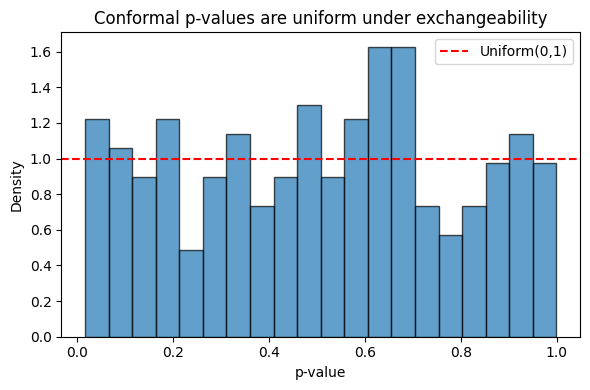

In [7]:
# Collect conformal p-values
cp_pv = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_pv.learn_initial_training_set(X_h[:50], y_h[:50])

p_values = []
for i in range(50, 300):
    p_values.append(cp_pv.compute_p_value(X_h[i], y_h[i]))
    cp_pv.learn_one(X_h[i], y_h[i])

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(p_values, bins=20, density=True, alpha=0.7, edgecolor="black")
ax.axhline(1.0, color="red", linestyle="--", label="Uniform(0,1)")
ax.set_xlabel("p-value")
ax.set_ylabel("Density")
ax.set_title("Conformal p-values are uniform under exchangeability")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. What about classification?

For classification, conformal prediction produces **prediction sets** — subsets of labels guaranteed to contain the true class. The interpretation:
- **Singleton** `{1}` → confident prediction
- **Multiple** `{0, 2}` → uncertain between those classes
- **Empty** `{}` → all labels look unusual (happens at most $\varepsilon$ of the time)

### 2.1 KNN classifier on Wine data

In [8]:
from online_cp import ConformalNearestNeighboursClassifier, SetSize

# Wine dataset (3 classes, 13 features)
wine = load_wine()
perm_w = rng.permutation(len(wine.target))
X_w, y_w = wine.data[perm_w], wine.target[perm_w]
labels = np.unique(y_w)

knn = ConformalNearestNeighboursClassifier(k=5, label_space=labels, rnd_state=42)
knn.learn_initial_training_set(X_w[:30], y_w[:30])

metric_knn = ErrorRate() + SetSize()
progressive_val(knn, X_w[30:], y_w[30:], epsilon=0.1, metric=metric_knn)

sizes = np.array(metric_knn["SetSize"].values)
print(f"Error rate: {metric_knn['ErrorRate'].get():.3f} (target ≤ 0.1)")
print(f"Average set size: {metric_knn['SetSize'].get():.2f}")
print(f"Singletons (confident): {np.mean(sizes == 1):.0%}")
print(f"Empty sets (anomalous): {np.mean(sizes == 0):.0%}")

Error rate: 0.101 (target ≤ 0.1)
Average set size: 1.50
Singletons (confident): 52%
Empty sets (anomalous): 1%


### 2.2 SVM classifier

`ConformalSupportVectorMachine` uses an RBF kernel and tends to produce **smaller** prediction sets (higher efficiency) at the cost of more computation:

In [9]:
from online_cp import ConformalSupportVectorMachine

svm = ConformalSupportVectorMachine(
    kernel="rbf", sigma=1.0, C=10.0, label_space=labels, rnd_state=42
)
svm.learn_initial_training_set(X_w[:30], y_w[:30])

metric_svm = ErrorRate() + SetSize()
progressive_val(svm, X_w[30:], y_w[30:], epsilon=0.1, metric=metric_svm)

print(f"KNN — error: {metric_knn['ErrorRate'].get():.3f}, avg set size: {metric_knn['SetSize'].get():.2f}")
print(f"SVM — error: {metric_svm['ErrorRate'].get():.3f}, avg set size: {metric_svm['SetSize'].get():.2f}")
print(f"\n→ Both satisfy the coverage guarantee. The nonconformity measure determines efficiency.")

KNN — error: 0.101, avg set size: 1.50
SVM — error: 0.088, avg set size: 2.61

→ Both satisfy the coverage guarantee. The nonconformity measure determines efficiency.


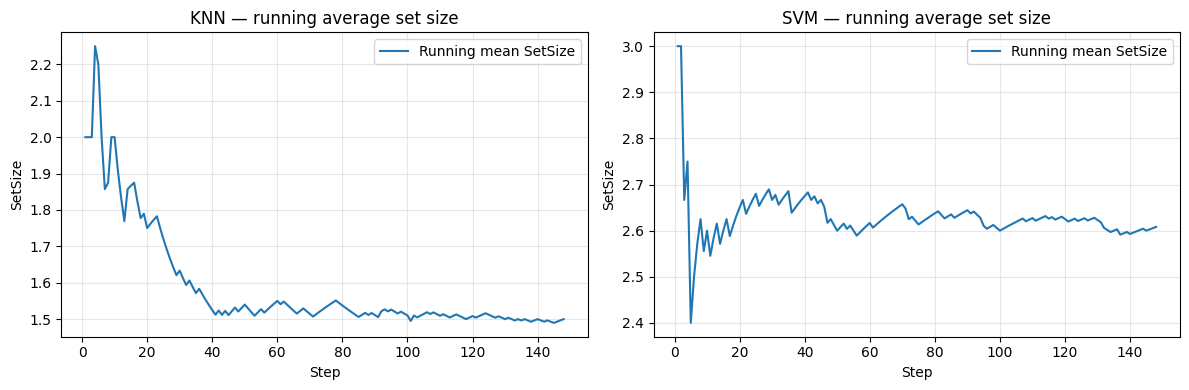

In [10]:
from online_cp.plotting import plot_set_sizes

# How does set size evolve as the model sees more data?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_set_sizes(metric_knn["SetSize"], ax=axes[0])
axes[0].set_title("KNN — running average set size")

plot_set_sizes(metric_svm["SetSize"], ax=axes[1])
axes[1].set_title("SVM — running average set size")

plt.tight_layout()
plt.show()


### 2.3 Multi-level predictions

Like a zoom lens — get predictions at multiple confidence levels in a single call:

In [11]:
# Multi-level prediction
knn2 = ConformalNearestNeighboursClassifier(k=5, label_space=labels, rnd_state=42)
knn2.learn_initial_training_set(X_w[:80], y_w[:80])

Gamma = knn2.predict(X_w[80], epsilon=[0.01, 0.05, 0.1, 0.2, 0.5])

print(f"True label: {y_w[80]}\n")
for eps, pred_set in Gamma:
    print(f"  ε={eps:.2f}: {pred_set.elements}  (size {len(pred_set)})")

print(f"\nCoverage check: {Gamma.coverage(y_w[80])}")

True label: 0

  ε=0.01: [0]  (size 1)
  ε=0.05: [0]  (size 1)
  ε=0.10: [0]  (size 1)
  ε=0.20: [0]  (size 1)
  ε=0.50: [0]  (size 1)

Coverage check: {0.01: True, 0.05: True, 0.1: True, 0.2: True, 0.5: True}


### 2.4 Venn-Abers — calibrated probabilities

Conformal predictors output **sets**, not probabilities. But sometimes you want a calibrated $P(y=1)$. The **Venn-Abers predictor** (Algorithm 6.1, ALRW2 §6.4) gives you a **multiprobability pair** $(p^0, p^1)$:

- $p^0$: calibrated probability assuming the true label is 0
- $p^1$: calibrated probability assuming the true label is 1

This pair IS the prediction — it is not an interval or a point estimate. When you need a single probability for decision-making, use the utility functions `log_loss_point(p0, p1)` or `brier_point(p0, p1)` (ALRW2 §6.4).

This is the **full/transductive** variant — no data splitting. The scorer is retrained on the augmented dataset for each hypothesis, then isotonically calibrated via the pool-adjacent-violators algorithm (PAVA).

In [12]:
from online_cp import VennAbersPredictor, log_loss_point, CalibrationError
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler

# Breast cancer dataset — binary classification
bc = load_breast_cancer()
perm_bc = rng.permutation(len(bc.target))
X_bc, y_bc = bc.data[perm_bc], bc.target[perm_bc]
scaler = StandardScaler()
X_bc_scaled = scaler.fit_transform(X_bc)

# Ridge-scored Venn-Abers predictor
vap = VennAbersPredictor(scorer="knn", k=1)
vap.learn_initial_training_set(X_bc_scaled[:50], y_bc[:50])

# Split examples into two groups by first feature (mean radius) for conditional calibration
median_radius_scaled = np.median(X_bc_scaled[:, 0])

# Stream predictions — collect the multiprobability pairs and VennPrediction objects
preds, p0s, p1s = [], [], []
labels_test = []
ce_large = CalibrationError()  # group: above-median mean radius
ce_small = CalibrationError()  # group: below-median mean radius

for i in range(50, 250):
    pred = vap.predict(X_bc_scaled[i])
    preds.append(pred)
    p0s.append(pred.p0)
    p1s.append(pred.p1)
    labels_test.append(y_bc[i])
    # Update per-group calibration error
    ce = ce_large if X_bc_scaled[i, 0] > median_radius_scaled else ce_small
    ce.update(y=y_bc[i], venn=pred)
    vap.learn_one(X_bc_scaled[i], y_bc[i])

p0s = np.array(p0s)
p1s = np.array(p1s)
labels_test = np.array(labels_test)

# For evaluation, merge pairs into single probabilities using log_loss_point
merged = np.array([log_loss_point(p0, p1) for p0, p1 in zip(p0s, p1s)])

print(f"Mean merged P(y=1) for true 1s: {merged[labels_test == 1].mean():.3f}")
print(f"Mean merged P(y=1) for true 0s: {merged[labels_test == 0].mean():.3f}")
print(f"\nAccuracy (threshold 0.5): {np.mean((merged > 0.5) == labels_test):.1%}")
print(f"Log loss: {log_loss(labels_test, merged):.3f}")


Mean merged P(y=1) for true 1s: 0.904
Mean merged P(y=1) for true 0s: 0.219

Accuracy (threshold 0.5): 93.0%
Log loss: 0.201


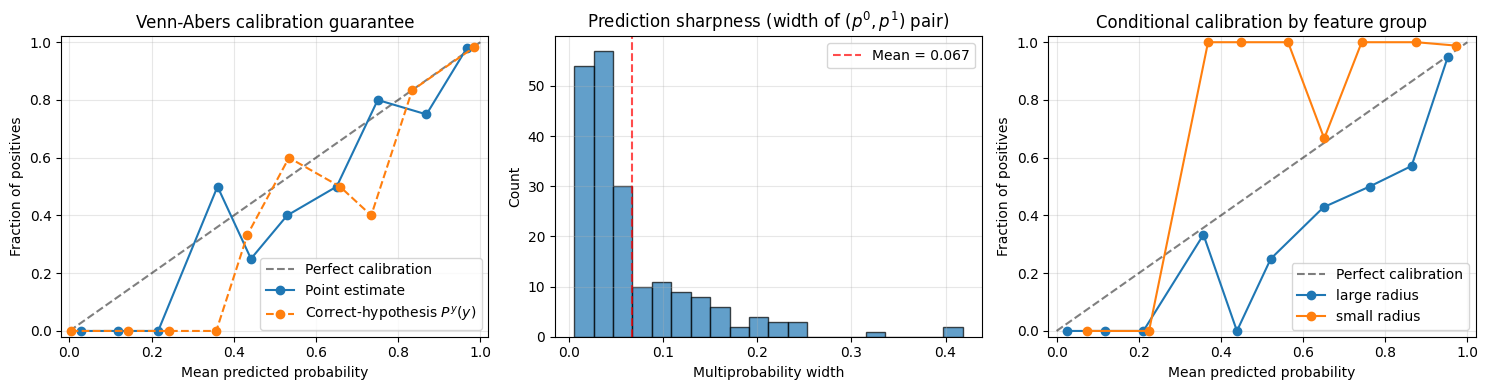

In [13]:
from online_cp.plotting import (
    plot_reliability_diagram_venn, plot_sharpness, plot_calibration_conditional
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: reliability diagram — shows the Venn validity guarantee in action
plot_reliability_diagram_venn(preds, labels_test, ax=axes[0])
axes[0].set_title("Venn-Abers calibration guarantee")

# Middle: sharpness — distribution of multiprobability width (p1 − p0)
plot_sharpness(preds, ax=axes[1])
axes[1].set_title("Prediction sharpness (width of $(p^0, p^1)$ pair)")

# Right: conditional calibration by tumour-size group
plot_calibration_conditional({"large radius": ce_large, "small radius": ce_small}, ax=axes[2])
axes[2].set_title("Conditional calibration by feature group")

plt.tight_layout()
plt.show()


Three plots, each showing a different facet of the Venn guarantee:

- **Reliability diagram** (`plot_reliability_diagram_venn`): the correct-hypothesis probability $P^y(y)$ is *theoretically calibrated* by Venn validity (ALRW2 Thm 6.4); the point estimate is calibrated empirically.
- **Sharpness** (`plot_sharpness`): histogram of multiprobability widths $p^1 - p^0$ — narrow pairs mean the predictor is informative; wide pairs mean genuine uncertainty.
- **Conditional calibration** (`plot_calibration_conditional`): ECE per feature group — confirms the Venn calibration holds across subpopulations, not just marginally.

The Venn-Abers predictor also supports **k-NN scoring** and **SVM scoring**:
```python
vap_knn = VennAbersPredictor(scorer="knn", k=5)
vap_svm = VennAbersPredictor(scorer="svm", kernel="rbf", sigma=1.0, C=10.0)
```

When you need a single probability for decision-making, use `log_loss_point(p0, p1)` (minimises log loss) or `brier_point(p0, p1)` (minimises Brier loss). For full utility-aware decisions under uncertainty, see §6.


---
## 3. Is it fair to everyone?

Standard conformal prediction guarantees **marginal** coverage — on average across all examples. But what if some subgroups are systematically undercovered?

**Mondrian conformal prediction** guarantees coverage *within each group*:

$$\mathbb{P}(y \in \Gamma^\varepsilon \mid \text{group} = k) \geq 1 - \varepsilon \quad \text{for each } k$$

The key: use a single pooled model but filter the calibration set to same-group examples.

In [14]:
from online_cp import MondrianConformalClassifier

# Breast Cancer dataset — split into groups by mean radius
bc = load_breast_cancer()
perm_bc = rng.permutation(len(bc.target))
X_bc, y_bc = bc.data[perm_bc], bc.target[perm_bc]
labels_bc = np.array([0, 1])

# Group: "large" vs "small" tumours (by median of mean radius, feature 0)
median_radius = np.median(X_bc[:, 0])
category_fn = lambda x: "large" if x[0] > median_radius else "small"

# Standard (marginal) conformal classifier
std_clf = ConformalNearestNeighboursClassifier(k=5, label_space=labels_bc, rnd_state=0)
std_clf.learn_initial_training_set(X_bc[:50], y_bc[:50])

# Mondrian (group-conditional) conformal classifier
mond_clf = MondrianConformalClassifier(
    base_model=ConformalNearestNeighboursClassifier(k=5, label_space=labels_bc),
    category_fn=category_fn,
)
mond_clf.learn_initial_training_set(X_bc[:50], y_bc[:50])

# Evaluate both, tracking errors by group
errors_std = {"large": [], "small": []}
errors_mond = {"large": [], "small": []}

for i in range(50, len(X_bc)):
    cat = category_fn(X_bc[i])

    pred_std = std_clf.predict(X_bc[i], epsilon=0.1)
    errors_std[cat].append(y_bc[i] not in pred_std)
    std_clf.learn_one(X_bc[i], y_bc[i])

    pred_mond = mond_clf.predict(X_bc[i], epsilon=0.1)
    errors_mond[cat].append(y_bc[i] not in pred_mond)
    mond_clf.learn_one(X_bc[i], y_bc[i])

print("Per-group error rates (target ≤ 0.1):")
print(f"{'Method':<12} {'Large':>8} {'Small':>8}")
print(f"{'Standard':<12} {np.mean(errors_std['large']):>8.3f} {np.mean(errors_std['small']):>8.3f}")
print(f"{'Mondrian':<12} {np.mean(errors_mond['large']):>8.3f} {np.mean(errors_mond['small']):>8.3f}")

Per-group error rates (target ≤ 0.1):
Method          Large    Small
Standard        0.187    0.058
Mondrian        0.107    0.109


The standard method satisfies *marginal* coverage but may undercovering one group. Mondrian CP guarantees each group gets at least $1 - \varepsilon$ coverage independently.

> **Note**: `MondrianConformalRegressor` works the same way for regression tasks.

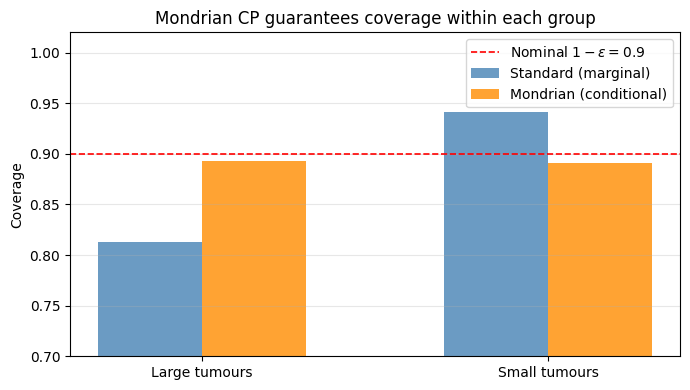

In [15]:
# Visualise the group-conditional coverage guarantee
groups = ["large", "small"]
fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(groups))
width = 0.3
coverage_std  = [1 - np.mean(errors_std[g])  for g in groups]
coverage_mond = [1 - np.mean(errors_mond[g]) for g in groups]

bars1 = ax.bar(x - width/2, coverage_std,  width, label="Standard (marginal)", color="steelblue",  alpha=0.8)
bars2 = ax.bar(x + width/2, coverage_mond, width, label="Mondrian (conditional)", color="darkorange", alpha=0.8)
ax.axhline(0.9, color="red", linestyle="--", linewidth=1.2, label="Nominal $1-\\varepsilon = 0.9$")

ax.set_xticks(x)
ax.set_xticklabels(["Large tumours", "Small tumours"])
ax.set_ylabel("Coverage")
ax.set_title("Mondrian CP guarantees coverage within each group")
ax.set_ylim(0.7, 1.02)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


---
## 4. What's the full picture?

Conformal Predictive Systems (CPS) go beyond intervals — they produce full **predictive distributions**. A conformal predictive distribution (CPD) assigns to each candidate value $y$ a probability $Q(y) \in [0, 1]$, and you can extract intervals at *any* level from it.

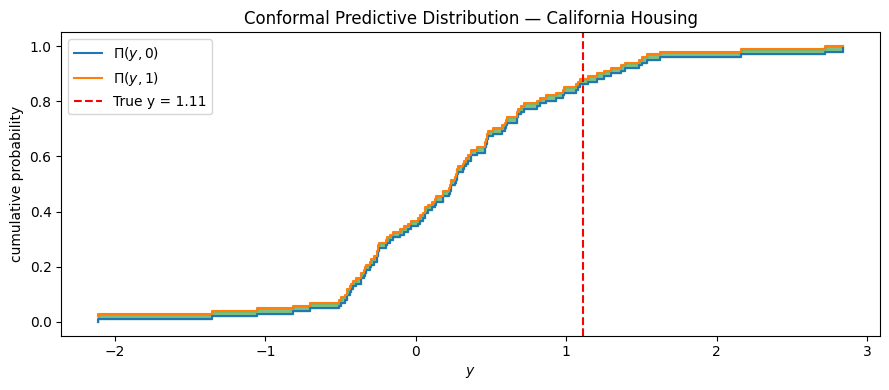

In [16]:
from online_cp import RidgePredictionMachine

# Use California Housing data
cps = RidgePredictionMachine(a=1.0)
cps.learn_initial_training_set(X_h[:100], y_h[:100])

# Get a conformal predictive distribution for one point
cpd = cps.predict(X_h[100])

fig = cpd.plot()
fig.set_size_inches(9, 4)
ax = fig.axes[0]
ax.axvline(y_h[100], color="red", linestyle="--", linewidth=1.5,
           label=f"True y = {y_h[100]:.2f}")
ax.legend()
ax.set_title("Conformal Predictive Distribution — California Housing")
fig.tight_layout()
fig

In [17]:
# Extract intervals at different levels from the same CPD
tau = rng.uniform()  # random tie-breaking
print(f"Intervals from one CPD (τ = {tau:.3f}):\n")
for eps in [0.01, 0.05, 0.1, 0.2]:
    iv = cpd.predict_set(tau, epsilon=eps)
    hit = "✓" if y_h[100] in iv else "✗"
    print(f"  ε={eps:.2f}: [{iv.lower:.2f}, {iv.upper:.2f}]  width={iv.width():.2f}  {hit}")

# The CPD evaluated at the true y is itself a p-value
p = cpd(y_h[100], tau)
print(f"\nCPD(y_true) = {p:.3f}  (a valid conformal p-value)")

Intervals from one CPD (τ = 0.212):

  ε=0.01: [-2.11, inf]  width=inf  ✓
  ε=0.05: [-1.05, 2.72]  width=3.77  ✓
  ε=0.10: [-0.70, 1.54]  width=2.24  ✓
  ε=0.20: [-0.46, 1.30]  width=1.75  ✓

CPD(y_true) = 0.863  (a valid conformal p-value)


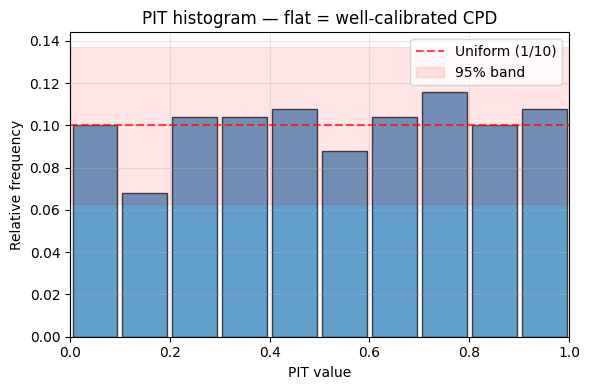

TruncatedCRPS (lower = better): 0.3768


In [18]:
from online_cp.plotting import plot_pit_histogram
from online_cp import TruncatedCRPS

# PIT (Probability Integral Transform) values: cpd evaluated at the true y
# Under a well-calibrated CPD these should be ~ Uniform[0,1]
cps_pit = RidgePredictionMachine(a=1.0)
cps_pit.learn_initial_training_set(X_h[:100], y_h[:100])

rng_tau = np.random.default_rng(7)
pit_values = []
crps_metric = TruncatedCRPS()

for i in range(100, 350):
    tau = rng_tau.uniform()
    cpd = cps_pit.predict(X_h[i])
    pit_values.append(cpd(y_h[i], tau))    # PIT value ∈ [0,1]
    crps_metric.update(y=y_h[i], cpd=cpd)  # TruncatedCRPS tracks predictive accuracy
    cps_pit.learn_one(X_h[i], y_h[i])

fig, ax = plt.subplots(figsize=(6, 4))
plot_pit_histogram(pit_values, ax=ax)
ax.set_title("PIT histogram — flat = well-calibrated CPD")
plt.tight_layout()
plt.show()

print(f"TruncatedCRPS (lower = better): {crps_metric.get():.4f}")


Other CPS variants: `KernelRidgePredictionMachine` (nonlinear), `NearestNeighboursPredictionMachine` (nonparametric), `DempsterHillConformalPredictiveSystem` (distribution-free).

---
## 5. Can I trust my data?

Conformal prediction assumes exchangeability. But what if the data distribution **shifts** over time? Conformal test martingales let you detect this *online*.

The idea: if p-values are truly uniform (exchangeability holds), a martingale $M_n$ satisfies $\mathbb{E}[M_n] \leq 1$. If the martingale grows large, it's evidence against exchangeability.

### 5.1 Exchangeable data — martingale stays flat

In [19]:
from online_cp import SimpleJumper
from online_cp.plotting import plot_martingale

# Exchangeable data: the California Housing data (already permuted)
cp_exch = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_exch.learn_initial_training_set(X_h[:50], y_h[:50])

mart_exch = SimpleJumper()
for i in range(50, 400):
    p = cp_exch.compute_p_value(X_h[i], y_h[i])
    mart_exch.update(p)
    cp_exch.learn_one(X_h[i], y_h[i])

print(f"Final martingale value: {mart_exch.M:.2f}  (stays small → data looks exchangeable)")

Final martingale value: 0.08  (stays small → data looks exchangeable)


### 5.2 Distribution shift — martingale explodes

Now let's simulate a sensor that drifts: the first 150 readings follow one distribution, then the mean shifts by 3.

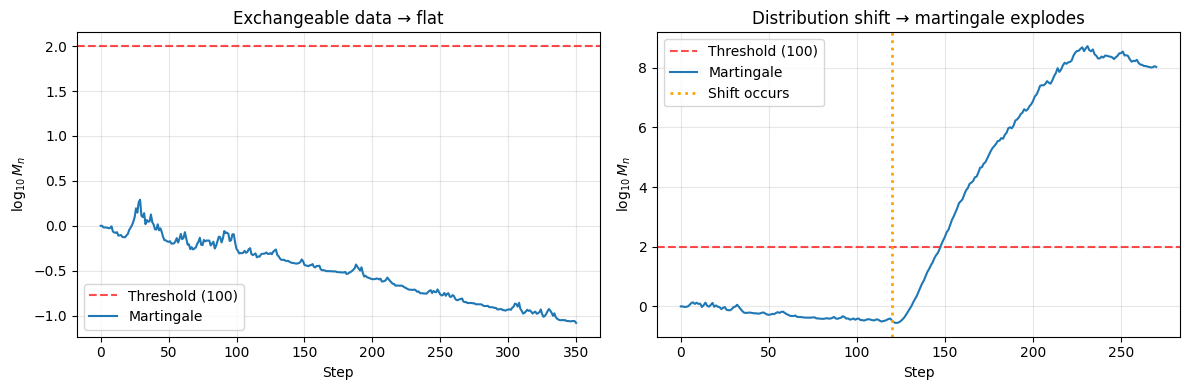


Max log-martingale after shift: 20.1
→ Strong evidence against exchangeability!


In [20]:
# Synthetic data with a shift at t=150
N_shift = 300
rng_s = np.random.default_rng(456)
X_s = rng_s.normal(size=(N_shift, 3))
y_s = np.empty(N_shift)
y_s[:150] = X_s[:150] @ [1, -1, 0.5] + rng_s.normal(0, 0.3, 150)
y_s[150:] = X_s[150:] @ [1, -1, 0.5] + 3.0 + rng_s.normal(0, 0.3, 150)  # mean shift!

cp_s = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_s.learn_initial_training_set(X_s[:30], y_s[:30])

mart_shift = SimpleJumper()
for i in range(30, N_shift):
    p = cp_s.compute_p_value(X_s[i], y_s[i])
    mart_shift.update(p)
    cp_s.learn_one(X_s[i], y_s[i])

# Plot both martingales side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_martingale(mart_exch, ax=axes[0])
axes[0].set_title("Exchangeable data → flat")

plot_martingale(mart_shift, ax=axes[1])
axes[1].axvline(150 - 30, color="orange", linestyle=":", linewidth=2, label="Shift occurs")
axes[1].legend()
axes[1].set_title("Distribution shift → martingale explodes")

plt.tight_layout()
plt.show()

print(f"\nMax log-martingale after shift: {max(mart_shift.log_martingale_values):.1f}")
print(f"→ Strong evidence against exchangeability!")

### 5.3 Ville's inequality — simple threshold test

The simplest way to turn a martingale into a hypothesis test: reject exchangeability the first time $M_n$ exceeds a threshold $c$. By **Ville's inequality**, $P(\exists n: M_n \geq c) \leq 1/c$, so setting $c = 20$ gives a test at the 5% significance level.

`VilleWrapper` wraps any base martingale and tracks the running maximum:

In [21]:
from online_cp import SimpleJumper, VilleWrapper

# Wrap a SimpleJumper with Ville's inequality at threshold=20 (5% significance)
ville = VilleWrapper(SimpleJumper(), threshold=20)

# Feed the same shifted data from Section 5.2
cp_v = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_v.learn_initial_training_set(X_s[:30], y_s[:30])

for i in range(30, N_shift):
    p = cp_v.compute_p_value(X_s[i], y_s[i])
    ville.update(p)
    cp_v.learn_one(X_s[i], y_s[i])
    if ville.rejected:
        print(f"✓ Exchangeability rejected at observation {i} (threshold={ville.threshold})")
        break

# With a stricter threshold (1% significance):
ville_strict = VilleWrapper(SimpleJumper(), threshold=100)
cp_v2 = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_v2.learn_initial_training_set(X_s[:30], y_s[:30])

for i in range(30, N_shift):
    p = cp_v2.compute_p_value(X_s[i], y_s[i])
    ville_strict.update(p)
    cp_v2.learn_one(X_s[i], y_s[i])

print(f"  With threshold=100 (1%): rejected={ville_strict.rejected}, max M={ville_strict.max:.1f}")

✓ Exchangeability rejected at observation 171 (threshold=20)
  With threshold=100 (1%): rejected=True, max M=532067750.9


### 5.4 Change-point detection with CUSUM and Shiryaev-Roberts wrappers

The `SimpleJumper` grows continuously once a shift occurs, but it never "resets" — so it's hard to pinpoint *when* the shift happened. Two classical wrappers solve this:

- **`CUSUMWrapper`** (Page, 1954): tracks the maximum ratio $\max_{0 \leq k \leq n} M_n / M_k$. It resets after each detection, making it ideal for detecting *multiple* change-points.
- **`ShiryaevRobertsWrapper`**: tracks the average ratio $\frac{1}{n}\sum_{k=0}^{n} M_n / M_k$. Often detects shifts slightly faster than CUSUM at the cost of more false alarms.

Both wrap *any* base martingale and inherit its betting strategy.

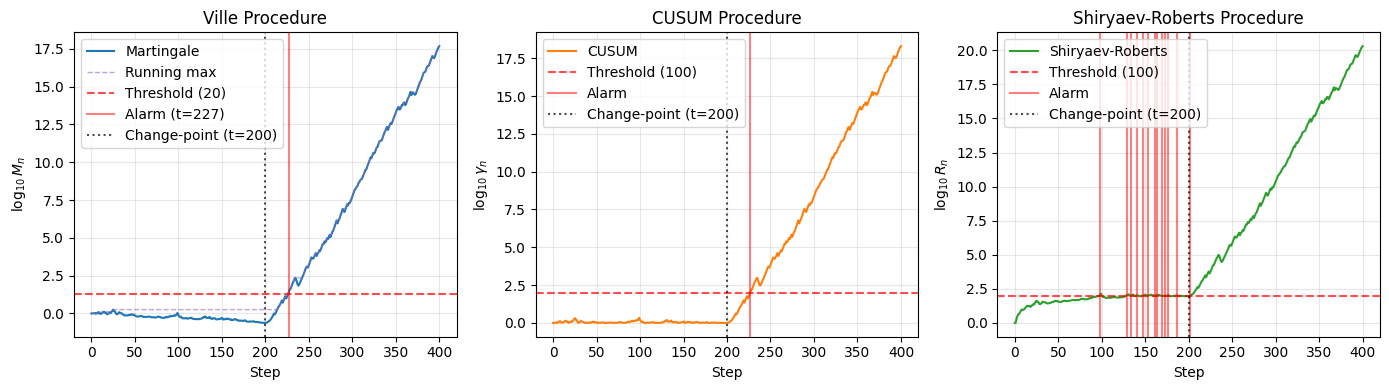

Ville: rejected=True at t=227
CUSUM γ=1993863689360077568.0, SR R=202919373232752787456.0
→ CUSUM and SR grow faster after the change-point.


In [22]:
from online_cp import SimpleJumper, CUSUMWrapper, ShiryaevRobertsWrapper, VilleWrapper
from online_cp.plotting import plot_detector

# Generate p-values: 200 from Uniform (exchangeable), then 200 from Beta(0.3, 1) (shift)
rng_cp = np.random.default_rng(42)
p_values = np.concatenate([
    rng_cp.uniform(size=200),
    rng_cp.beta(0.3, 1.0, size=200),
])

# Run three wrappers on the same p-values
ville = VilleWrapper(SimpleJumper(), threshold=20)
cusum = CUSUMWrapper(SimpleJumper())
sr = ShiryaevRobertsWrapper(SimpleJumper())

for p in p_values:
    ville.update(p)
    cusum.update(p)
    sr.update(p)

# Plot with plot_detector — one call per wrapper
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_detector(ville, change_point=200, ax=axes[0])
plot_detector(cusum, threshold=100, change_point=200, ax=axes[1])
plot_detector(sr, threshold=100, change_point=200, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Ville: rejected={ville.rejected} at t={ville.rejection_time}")
print(f"CUSUM γ={cusum.gamma:.1f}, SR R={sr.R:.1f}")
print("→ CUSUM and SR grow faster after the change-point.")

### 5.5 Sleeper martingales

The **SleeperStayer** martingale (Algorithm 9.4, ALRW2) maintains a pool of "sleeper" experts that wake up at every time step, allowing it to detect change-points at *unknown* locations without knowing the shift timescale in advance.

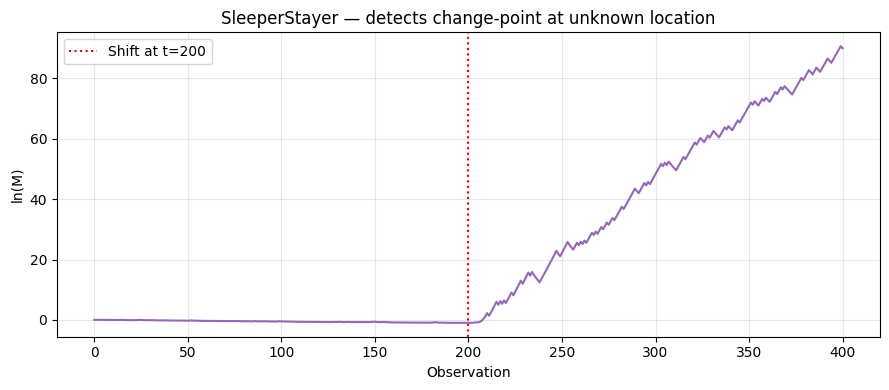

Final ln(M): 90.0
→ SleeperStayer grows rapidly after the shift, without knowing when it occurs.


In [23]:
from online_cp import SleeperStayer

# Same p-values as before: shift at t=200
mart_sleeper = SleeperStayer(R=0.01, G=5)

for p in p_values:
    mart_sleeper.update(p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mart_sleeper.log_martingale_values, color="tab:purple", linewidth=1.5)
ax.axvline(200, color="red", linestyle=":", linewidth=1.5, label="Shift at t=200")
ax.set_xlabel("Observation")
ax.set_ylabel("ln(M)")
ax.set_title("SleeperStayer — detects change-point at unknown location")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final ln(M): {mart_sleeper.logM:.1f}")
print("→ SleeperStayer grows rapidly after the shift, without knowing when it occurs.")

**Martingale classes available:**
- Base: `PluginMartingale`, `SimpleMixtureMartingale`, `SimpleJumper`, `CompositeJumper`
- Change-point: `VilleWrapper`, `CUSUMWrapper`, `ShiryaevRobertsWrapper`, `SleeperStayer`, `SleeperDrifter`
- Betting strategies: `GaussianKDE`, `BetaKernel`, `BetaMoments`, `BetaMLE`, `PiecewiseConstantBetting`

See the [API docs](https://egonmedhatten.github.io/online-cp/api/martingale/) for full details.

---
## 6. Putting it into production

The `evaluate` module provides a clean interface for streaming evaluation without manual loops.

### 6.1 `progressive_val` — the standard evaluation loop

You've already seen this above. It runs test-then-train and updates metrics:

### 6.1 Defining a utility function

A `UtilityFunction` bundles a payoff rule $U(x, y, d) \to \mathbb{R}$ with the set of available decisions $\mathcal{D}$. In a medical screening example:

- **Decision `"treat"`**: costs 5 but avoids outcome cost 20 if condition is present
- **Decision `"wait"`**: no cost, but you pay 20 if condition is present and untreated

```
U(x, y, d)  =  { -5      if d="treat"
               { -20·y   if d="wait"  (y=1 means condition present)
```


In [24]:
from online_cp import (
    UtilityFunction, ConformalPredictiveDecisionMaker,
    cps_decision, venn_decision, RidgePredictionMachine
)

# Utility: treat (-5 always) vs wait (-20 if malignant, 0 otherwise)
# y encodes RUL as a continuous value; here we use a regression stand-in.
# For illustration we use a simple asymmetric regression cost:
#   d is a candidate threshold; U = -(y - d)^2 with an asymmetric penalty
decisions = [-20, -10, 0, 10, 20]  # candidate action values
utility = UtilityFunction(
    fn=lambda x, y, d: -(y - d)**2,
    decisions=decisions,
)
print(f"Decision space: {decisions}")
print(f"U(x, y=5, d=0)  = {utility(None, 5,  0):.1f}")
print(f"U(x, y=5, d=10) = {utility(None, 5, 10):.1f}")


Decision space: [-20, -10, 0, 10, 20]
U(x, y=5, d=0)  = -25.0
U(x, y=5, d=10) = -25.0


### 6.2 `ConformalPredictiveDecisionMaker` — Vovk & Bendtsen Algorithm 1

The exact algorithm trains **one CPS per decision** on utility-transformed labels $\tilde{y}_d = U(x, y, d)$. At prediction time it reads off the expected utility from each CPS's predictive distribution and picks $\arg\max_d \mathbb{E}[U | x, d]$.

This is strictly more principled than applying a single CPD post-hoc: the model is calibrated *on the utility scale*, not on raw labels.


In [25]:
# ConformalPredictiveDecisionMaker: one Ridge CPS per decision, trained on utility labels
dm = ConformalPredictiveDecisionMaker(utility, cps_class=RidgePredictionMachine, a=1.0)
dm.learn_initial_training_set(X_h[:80], y_h[:80])

# Show expected utilities for one test point
tau = rng.uniform()
eu = dm.predict_expected_utilities(X_h[80], tau=tau)
best = dm.predict(X_h[80], tau=tau)

print(f"True y = {y_h[80]:.2f}")
print("\nExpected utilities per decision:")
for d, u in eu.items():
    marker = "  ← optimal" if d == best else ""
    print(f"  d={d:+4d}:  E[U] = {u:+.2f}{marker}")

# Run a mini evaluation loop
dm2 = ConformalPredictiveDecisionMaker(utility, cps_class=RidgePredictionMachine, a=1.0)
dm2.learn_initial_training_set(X_h[:80], y_h[:80])

decisions_made, true_utilities = [], []
for i in range(80, 180):
    tau_i = rng.uniform()
    d_star = dm2.predict(X_h[i], tau=tau_i)
    decisions_made.append(d_star)
    true_utilities.append(utility(X_h[i], y_h[i], d_star))
    dm2.learn_one(X_h[i], y_h[i])

print(f"\nOver 100 test examples:")
print(f"  Mean realised utility: {np.mean(true_utilities):.2f}")
print(f"  Decision distribution: { {d: decisions_made.count(d) for d in decisions} }")


True y = 1.57

Expected utilities per decision:
  d= -20:  E[U] = -473.90
  d= -10:  E[U] = -142.10
  d=  +0:  E[U] = -4.80  ← optimal
  d= +10:  E[U] = -61.19
  d= +20:  E[U] = -311.73

Over 100 test examples:
  Mean realised utility: -5.26
  Decision distribution: {-20: 0, -10: 0, 0: 99, 10: 1, 20: 0}


### 6.3 Venn-PDMS — decision-making under multiprobability uncertainty

For binary classifiers, `venn_decision` selects the optimal decision using the Venn multiprobability pair $(p^0, p^1)$ and an **α-utility** (or α-regret) criterion. Because the Venn pair expresses *genuine uncertainty*, the criterion interpolates between:

- $\alpha = 0$: **maximin** — optimise for the worst-case hypothesis (conservative)
- $\alpha = 1$: **maximax** — optimise for the best-case hypothesis (optimistic)
- $\alpha = 0.5$: midpoint (expected value under equal weighting)


In [26]:
from online_cp import venn_decision

# Breast cancer screening: treat (-cost_treat) vs watch-and-wait (-big_penalty if malignant)
screening_utility = UtilityFunction(
    fn=lambda x, y, d: -5 if d == "treat" else (-20 * y),
    decisions=["treat", "wait"],
)

# Use the vap trained in §2.4 (already learned on 200 examples)
# Compare decision criteria for a few test examples
vap_test = VennAbersPredictor(scorer="knn", k=1)
vap_test.learn_initial_training_set(X_bc_scaled[:50], y_bc[:50])

print(f"{'Example':>8}  {'y':>3}  {'maximin (α=0)':>14}  {'midpoint (α=0.5)':>17}  {'maximax (α=1)':>13}")
print("-" * 62)
for i in range(50, 65):
    pred = vap_test.predict(X_bc_scaled[i])
    d_pessimistic = venn_decision(pred, screening_utility, X_bc_scaled[i], criterion="utility", alpha=0.0)
    d_midpoint    = venn_decision(pred, screening_utility, X_bc_scaled[i], criterion="utility", alpha=0.5)
    d_optimistic  = venn_decision(pred, screening_utility, X_bc_scaled[i], criterion="utility", alpha=1.0)
    print(f"  ex {i - 50 + 1:>3d}    {y_bc[i]:>1}   {d_pessimistic:>14}  {d_midpoint:>17}  {d_optimistic:>13}")
    vap_test.learn_one(X_bc_scaled[i], y_bc[i])

print("\n→ Conservative (α=0) tends to treat more; optimistic (α=1) waits more.")
print("→ The right α depends on the relative cost of false positives vs false negatives.")


 Example    y   maximin (α=0)   midpoint (α=0.5)  maximax (α=1)
--------------------------------------------------------------
  ex   1    1            treat              treat          treat
  ex   2    1            treat              treat          treat
  ex   3    1            treat              treat          treat
  ex   4    1            treat              treat          treat
  ex   5    1            treat              treat          treat
  ex   6    1            treat              treat           wait
  ex   7    0            treat              treat          treat
  ex   8    0            treat              treat          treat
  ex   9    1            treat              treat          treat
  ex  10    1            treat              treat          treat
  ex  11    0            treat              treat          treat
  ex  12    0            treat              treat          treat
  ex  13    1            treat              treat          treat
  ex  14    1            tre

For a full end-to-end case study — streaming decisions over a simulated industrial fleet with Mondrian coverage, `ConformalPredictiveDecisionMaker`, delayed labels (Weak Teacher), and a live dashboard — see [`notebooks/production-pipeline.ipynb`](production-pipeline.ipynb).

---
## 7. Putting it into production

The `evaluate` module provides a clean interface for streaming evaluation without manual loops.

### 7.1 `progressive_val` — the standard evaluation loop

You've already seen this above. It runs test-then-train and updates metrics:


In [27]:
from online_cp.evaluate import iter_progressive_val

# iter_progressive_val yields periodic snapshots — great for learning curves
model_prod = ConformalRidgeRegressor(a=1.0)
model_prod.learn_initial_training_set(X_h[:50], y_h[:50])

metric_prod = ErrorRate() + IntervalWidth()
snapshots = list(iter_progressive_val(
    model_prod, X_h[50:], y_h[50:], epsilon=0.1, metric=metric_prod, step=50
))

print("Learning curve (checkpoints every 50 steps):")
for s in snapshots:
    print(f"  Step {s['step']:3d}: error={s['ErrorRate']:.3f}, width={s['IntervalWidth']:.2f}")

Learning curve (checkpoints every 50 steps):
  Step  50: error=0.080, width=2.52
  Step 100: error=0.100, width=2.32
  Step 150: error=0.100, width=2.31
  Step 200: error=0.090, width=2.27
  Step 250: error=0.100, width=2.24
  Step 300: error=0.107, width=2.23
  Step 350: error=0.111, width=2.23
  Step 400: error=0.130, width=2.25
  Step 450: error=0.136, width=2.26
  Step 500: error=0.132, width=2.27
  Step 550: error=0.122, width=2.28


### 6.2 Conditional learning

In practice, labels may arrive with delay or only for a subset of predictions. The `learn` parameter controls when the model updates:

In [28]:
# Simulate 50% label availability
model_cond = ConformalRidgeRegressor(a=1.0)
model_cond.learn_initial_training_set(X_h[:50], y_h[:50])

m_full = ErrorRate() + IntervalWidth()
m_half = ErrorRate() + IntervalWidth()

# Full learning
model_full = ConformalRidgeRegressor(a=1.0)
model_full.learn_initial_training_set(X_h[:50], y_h[:50])
progressive_val(model_full, X_h[50:300], y_h[50:300], epsilon=0.1, metric=m_full)

# 50% learning
progressive_val(
    model_cond, X_h[50:300], y_h[50:300], epsilon=0.1, metric=m_half,
    learn=lambda i, x, y: i % 2 == 0
)

print(f"100% labels: {m_full}")
print(f" 50% labels: {m_half}")
print(f"\n→ Coverage guarantee still holds! But intervals are wider with fewer labels.")

100% labels: ErrorRate: 0.1000
IntervalWidth: 2.2434
 50% labels: ErrorRate: 0.1000
IntervalWidth: 2.3605

→ Coverage guarantee still holds! But intervals are wider with fewer labels.


### 6.3 Composable metrics

Metrics combine with `+` and provide running statistics:

| Metric | For | Description |
|--------|-----|-------------|
| `ErrorRate` | All | Fraction outside prediction set |
| `IntervalWidth` | Regression | Average interval width |
| `WinklerScore` | Regression | Penalises width + miscoverage |
| `SetSize` | Classification | Average prediction set size |
| `ObservedFuzziness` | All | Calibration via p-values |
| `CRPS` | CPS | Continuous Ranked Probability Score |

---
## Summary

### API at a glance

```python
model = ConformalRidgeRegressor(a=1.0)
model.learn_initial_training_set(X_train, y_train)

interval = model.predict(x_new, epsilon=0.1)       # single level
result   = model.predict(x_new, epsilon=[...])     # multi-level
p        = model.compute_p_value(x_new, y_new)     # p-value
model.learn_one(x_new, y_new)                      # online update

# Evaluation
metric = ErrorRate() + IntervalWidth()
progressive_val(model, X_test, y_test, epsilon=0.1, metric=metric, progress=True)

# Decision-making
dm = ConformalPredictiveDecisionMaker(utility, cps_class=RidgePredictionMachine, a=1.0)
dm.learn_initial_training_set(X_train, y_train)
optimal_decision = dm.predict(x_new)
```

### Available models

| Category | Classes |
|----------|--------|
| **Regressors** | `ConformalRidgeRegressor`, `KernelConformalRidgeRegressor`, `ConformalLassoRegressor`, `ConformalNearestNeighboursRegressor` |
| **Classifiers** | `ConformalNearestNeighboursClassifier`, `ConformalSupportVectorMachine` |
| **Venn Predictors** | `VennAbersPredictor` (ridge, k-NN, SVM scoring), `NearestNeighboursVennPredictor` |
| **Mondrian** | `MondrianConformalRegressor`, `MondrianConformalClassifier` |
| **CPS** | `RidgePredictionMachine`, `KernelRidgePredictionMachine`, `NearestNeighboursPredictionMachine` |
| **Decision** | `ConformalPredictiveDecisionMaker`, `UtilityFunction`, `venn_decision`, `cps_decision` |
| **Martingales** | `PluginMartingale`, `SimpleMixtureMartingale`, `SimpleJumper`, `CompositeJumper`, `SleeperStayer`, `SleeperDrifter` |
| **Detection Wrappers** | `VilleWrapper`, `CUSUMWrapper`, `ShiryaevRobertsWrapper` |
| **Kernels** | `GaussianKernel`, `LinearKernel`, `PolynomialKernel`, `PeriodicKernel`, `LinearCombinationKernel`, `ProductKernel` |

### Plotting utilities

| Function | Shows |
|----------|-------|
| `plot_coverage` | Running coverage vs nominal level |
| `plot_intervals` | Prediction intervals vs true values |
| `plot_set_sizes` | Running average prediction set size |
| `plot_martingale` | Martingale trajectory (log scale) |
| `plot_detector` | CUSUM / Ville / SR statistic with alarm markers |
| `plot_pit_histogram` | PIT histogram — calibration check for CPDs |
| `plot_reliability_diagram` | Calibration curve (predicted vs observed frequency) |
| `plot_reliability_diagram_venn` | Venn-Abers calibration guarantee visualised |
| `plot_sharpness` | Distribution of multiprobability widths |
| `plot_calibration_conditional` | Per-group reliability diagrams (Mondrian lens) |

### Looking for Inductive (Split) Conformal Prediction?

This package focuses on **online** (transductive) conformal prediction. For **inductive** (split) conformal methods — where you have a fixed pre-trained model and a held-out calibration set — we recommend the [`crepes`](https://github.com/henrikbostrom/crepes) package.

### References

- Vovk, Gammerman, Shafer. *Algorithmic Learning in a Random World* (2nd ed). Springer, 2022.
- Vovk, Bendtsen. *Conformal predictive decision making*. COPA, 2018.
- Lei. *Fast exact conformalization of the lasso using piecewise linear homotopy*. Biometrika, 2019.
